In [1]:
import sys
sys.path.append('../')
import os
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from src.IO import ExperimentLoader
from src.environment import LigandEnvironment, LogNormalConcentration
from src.physics import BinaryReceptor
from objectives.loss import ExactInformationLoss
from src import plot_latent_umap

PARAMETER SWEEP
The script runs a massive parallelized sweep across varying levels of environmental complexity and genetic restrictions:
- `n_families` (Environmental Complexity): [1, 2, 3, 5, 10, 20]
- `latent_dim` (Chemical Space Dimension): [3, 7, 10]
- `n_units` (Number of Available Genes): [1, 2, 3, 5, 7, 8, 10, 12, 15, 20, 30, 50]
- `n_samples` (Trials): 5 independent simulation runs per configuration to measure statistical variance and stability.

OUTPUTS
Data is recursively saved to: `/app/data/families_<n_families>/dim_<latent_dim>/n_units_<n_units>/sample_<sample_id>/`
Each run folder generates:
- `config.json`: The specific parameters for the trial.
- `stats.csv`: Epoch-by-epoch training metrics, including the array's differential entropy and mean receptor distances.
- `best_model.pt`: The optimized neural network/environment weights.
- `test_results.json`: Independent post-training evaluation measurements of the array's entropy, used to calculate confidence intervals and standard deviations.

By increasing both the number of families and the latent dimension, the simulation assesses how effectively combinatorial receptor arrays (homomeric vs. heteromeric) can break the "discretization bottleneck" and utilize their full theoretical coding capacity in highly complex environments.

In [2]:
# Load all experiments across the parameter sweep
base_paths = {
    'homomers': Path("../data/homomers_w/"),
    'heteromers': Path("../data/heteromers/")
    #'heteromers': Path("../data/series_2/heteromers/")
    #'homomers': Path("../data/series_1/homomers/"),
    #'heteromers': Path("../data/series_1/heteromers/")
}
experiments = {}

for exp_type, base_data_path in base_paths.items():
    if not base_data_path.exists():
        continue
    for f_dir in base_data_path.glob("families_*"):
        n_families = int(f_dir.name.split("_")[1])
        for d_dir in f_dir.glob("dim_*"):
            latent_dim = int(d_dir.name.split("_")[1])
            for u_dir in d_dir.glob("n_units_*"):
                n_units = int(u_dir.name.split("_")[2])
                receptor_dirs = list(u_dir.glob("n_receptors_*")) if exp_type == 'heteromers' else [u_dir]
                
                for r_dir in receptor_dirs:
                    n_receptors = int(r_dir.name.split("_")[2]) if exp_type == 'heteromers' else n_units
                    config_key = (exp_type, n_families, latent_dim, n_units, n_receptors)
                    
                    if config_key not in experiments:
                        experiments[config_key] = {'samples': [], 'test_entropies': []}
                    
                    for sample_dir in r_dir.glob("sample_*"):
                        try:
                            loader = ExperimentLoader(base_path=str(r_dir), experiment_name=sample_dir.name)
                            env, physics, loss_fn, receptor_indices, stats_df, config = loader.load_objects(filename="best_model.pt")
                            
                            # Initialize containers for the metrics
                            test_json_path = sample_dir / "test_results.json"
                            metrics = {
                                "full_array_entropy": [],
                                "mutual_information_family": None,
                                "mutual_information_concentration": None
                            }

                            if test_json_path.exists():
                                with open(test_json_path, "r") as f:
                                    data = json.load(f)
                                    # Get the entropy list (default to empty list if missing)
                                    metrics["full_array_entropy"] = data.get("full_array_entropy", [])
                                    # Get the specific MI metrics (default to None or 0.0)
                                    metrics["mutual_information_family"] = data.get("mutual_information_family")
                                    metrics["mutual_information_concentration"] = data.get("mutual_information_concentration")

                            # Append to experiments dictionary
                            experiments[config_key]['samples'].append({
                                'env': env, 
                                'physics': physics, 
                                'receptor_indices': receptor_indices,
                                'stats_df': stats_df, 
                                'config': config,
                                'test_entropies': metrics["full_array_entropy"],
                                'mi_family': metrics["mutual_information_family"],
                                'mi_concentration': metrics["mutual_information_concentration"]
                            })
                            
                            # Keep track of aggregated entropies if your downstream analysis requires it
                            experiments[config_key]['test_entropies'].extend(metrics["full_array_entropy"])

                        except Exception as e:
                            print(f"Error loading {sample_dir}: {e}")
                            pass

print(f"Loaded {len(experiments)} unique configurations.")

Auto-discovered latest run: sample_3_20260418_181232
Auto-discovered latest run: sample_2_20260418_180910
Auto-discovered latest run: sample_0_20260418_180240
Auto-discovered latest run: sample_4_20260418_094334
Auto-discovered latest run: sample_3_20260418_094237
Auto-discovered latest run: sample_1_20260418_180551
Auto-discovered latest run: sample_1_20260418_094042
Auto-discovered latest run: sample_0_20260418_093944
Auto-discovered latest run: sample_2_20260418_094140
Auto-discovered latest run: sample_4_20260418_181554
Auto-discovered latest run: sample_4_20260418_181447
Auto-discovered latest run: sample_2_20260418_180759
Auto-discovered latest run: sample_0_20260418_180211
Auto-discovered latest run: sample_3_20260418_094217
Auto-discovered latest run: sample_1_20260418_094022
Auto-discovered latest run: sample_4_20260418_094314
Auto-discovered latest run: sample_1_20260418_180439
Auto-discovered latest run: sample_0_20260418_093924
Auto-discovered latest run: sample_3_20260418_

In [3]:
# Example: viewing stats for Homomers, Families=5, Dim=10, Units=10 (Sample 0)
example_key = ('homomers', 30, 3, 1,1)
if example_key in experiments and len(experiments[example_key]['samples']) > 0:
    display(experiments[example_key]['samples'][0].keys())
else:
    print('not in the folder')
print(experiments[example_key]['samples'][0]['config'])

dict_keys(['env', 'physics', 'receptor_indices', 'stats_df', 'config', 'test_entropies', 'mi_family', 'mi_concentration'])

{'n_families': 30, 'latent_dim': 3, 'average_family_distance': 5.0, 'shape_sigma': 0.1, 'use_sensitivity': False, 'init_means': [3.9305161565368554, 4.228598876632314, 4.136048505120327, 4.430260455386817, 3.2087922255834807, 4.2014499400232905, 3.706031662628874, 4.7692948527676045, 3.6053254091206575, 3.0462931030510125, 4.798657883756032, 4.882049678530517, 3.023033457816365, 4.220613084411072, 4.000572043930887, 4.580307875882087, 3.9013731089313044, 4.750357509596554, 4.034647695243301, 4.508904616312763, 4.199905438415172, 3.1653675472789558, 3.2250946459050107, 3.597166010433888, 3.861594929059709, 4.996438858855516, 3.3350665793419796, 4.469508880593616, 3.763898850883798, 4.62666241687121], 'k_sub': 5, 'temperature': 0.1, 'n_units': 1, 'receptor_indices': [[0, 0, 0, 0, 0]], 'batch_size': 4096, 'epochs': 500, 'lr': 0.05, 'loss': 'exact', 'entropy': 'renyi', 'use_scheduler': False}


/tmp/ipykernel_12151/1967429867.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[r, c].legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')


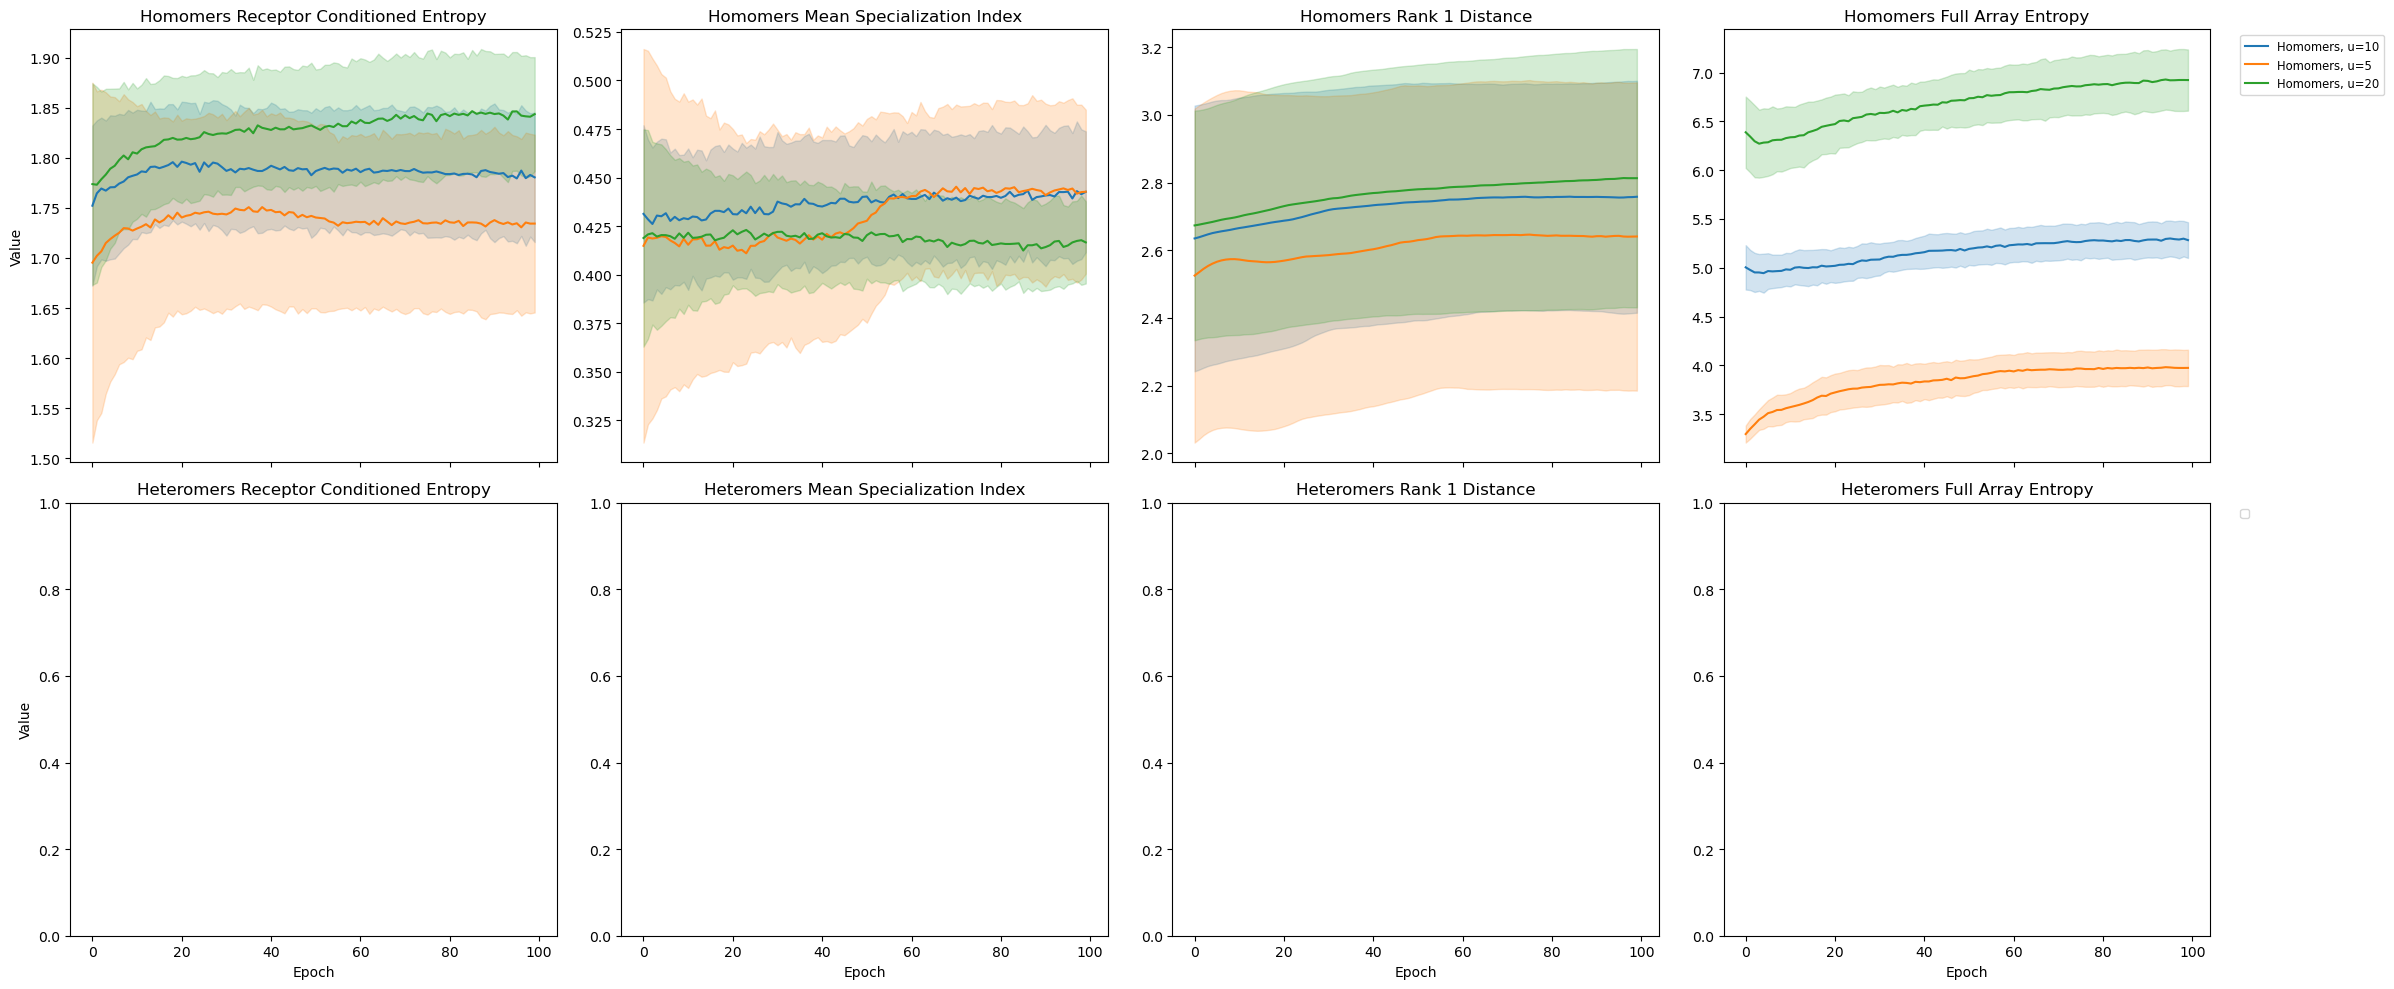

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the training metrics (Mean & Std Dev) for a specific configuration
target_families = 5
target_dim = 3

# Sub-sample choices (customize as needed)
selected_units = [5, 10, 20]
selected_receptors = [5, 10, 20]

# Adjust grid to 2 rows and 4 columns
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(24, 10), sharex=True)

for config_key, exp_data in experiments.items():
    # Unpack config tuple
    exp_type, n_families, latent_dim, n_units, n_receptors = config_key
    
    # Filter based on targets
    if n_families != target_families or latent_dim != target_dim or not exp_data['samples']:
        continue
    if n_units not in selected_units:
        continue
    if exp_type == 'heteromers' and n_receptors not in selected_receptors:
        continue
    
    # Extract time-series arrays from stats_df
    all_rce = [s['stats_df']['receptor_conditioned_entropy'].values for s in exp_data['samples']]
    all_msi = [s['stats_df']['mean_specialization_index'].values for s in exp_data['samples']]
    all_rank_dist = [s['stats_df']['dist_rank_1'].values for s in exp_data['samples']]
    all_fae = [s['stats_df']['full_array_entropy'].values for s in exp_data['samples']] # Added FAE
    
    epochs = exp_data['samples'][0]['stats_df']['epoch'].values
    
    # Standardize length if samples got interrupted mid-training
    min_len = min(len(e) for e in all_rce)
    all_rce = [e[:min_len] for e in all_rce]
    all_msi = [m[:min_len] for m in all_msi]
    all_rank_dist = [r[:min_len] for r in all_rank_dist]
    all_fae = [f[:min_len] for f in all_fae] # Added FAE standardization
    epochs = epochs[:min_len]
    
    # Calculate means and standard deviations across the samples
    def get_stats(data_list):
        return np.mean(data_list, axis=0), np.std(data_list, axis=0)

    mean_rce, std_rce = get_stats(all_rce)
    mean_msi, std_msi = get_stats(all_msi)
    mean_rank, std_rank = get_stats(all_rank_dist)
    mean_fae, std_fae = get_stats(all_fae) # Added FAE stats
    
    row = 0 if exp_type == 'homomers' else 1
    label = f'Homomers, u={n_units}' if exp_type == 'homomers' else f'Heteromers, u={n_units}, r={n_receptors}'
    
    # Column 0: Receptor Conditioned Entropy
    p = ax[row, 0].plot(epochs, mean_rce, label=label)
    ax[row, 0].fill_between(epochs, mean_rce - std_rce, mean_rce + std_rce, color=p[0].get_color(), alpha=0.2)
    
    # Column 1: Mean Specialization Index
    p = ax[row, 1].plot(epochs, mean_msi, label=label)
    ax[row, 1].fill_between(epochs, mean_msi - std_msi, mean_msi + std_msi, color=p[0].get_color(), alpha=0.2)

    # Column 2: Rank 1 Distance
    p = ax[row, 2].plot(epochs, mean_rank, label=label)
    ax[row, 2].fill_between(epochs, mean_rank - std_rank, mean_rank + std_rank, color=p[0].get_color(), alpha=0.2)
    
    # Column 3: Full Array Entropy
    p = ax[row, 3].plot(epochs, mean_fae, label=label)
    ax[row, 3].fill_between(epochs, mean_fae - std_fae, mean_fae + std_fae, color=p[0].get_color(), alpha=0.2)

# Formatting Headings and Labels
titles = ["Receptor Conditioned Entropy", "Mean Specialization Index", "Rank 1 Distance", "Full Array Entropy"]
for r, row_name in enumerate(["Homomers", "Heteromers"]):
    for c in range(4): # Loop expanded to 4 columns
        ax[r, c].set_title(f"{row_name} {titles[c]}")
        if r == 1: ax[r, c].set_xlabel('Epoch')
        if c == 0: ax[r, c].set_ylabel('Value')
        
        # Moved legend to the 4th column
        if c == 3: 
            ax[r, c].legend(fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

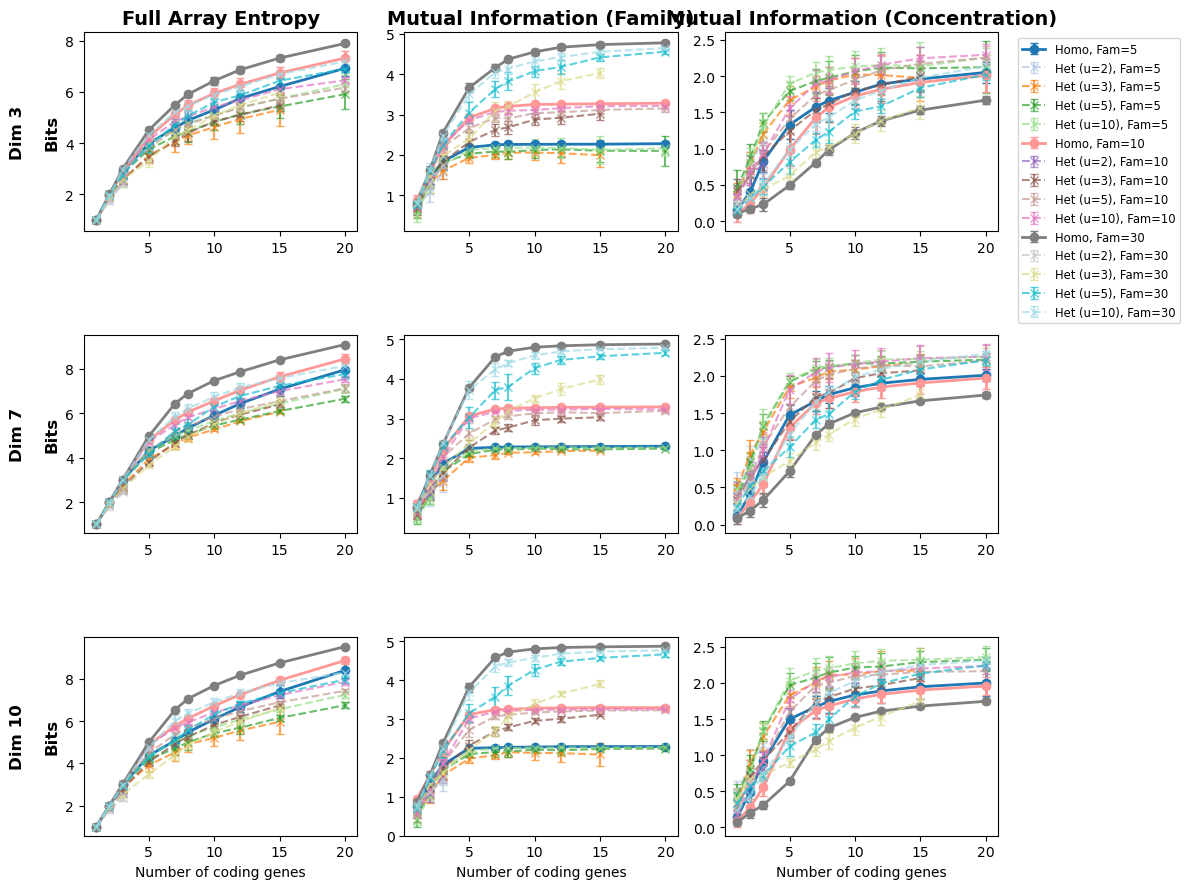

In [5]:
# Define dimensions to plot
dims_to_plot = [3,7,10]
families_to_plot = [5,10,30]
het_units_to_plot = [2,3,5,10]

# Define the metrics
metrics_info = [
    {'key': 'test_entropies', 'label': 'Test Entropy', 'title': 'Full Array Entropy'},
    {'key': 'mi_family', 'label': 'MI Family', 'title': 'Mutual Information (Family)'},
    {'key': 'mi_concentration', 'label': 'MI Concentration', 'title': 'Mutual Information (Concentration)'}
]

# Create a grid: Rows = Dimensions, Cols = Metrics
n_dims = len(dims_to_plot)
fig, axes = plt.subplots(nrows=n_dims, ncols=3, figsize=(3*4, 3 * n_dims), squeeze=False)

def get_plot_data(exp_dict, exp_type, fam, dim, metric_key, n_units=None):
    """Filters and sorts data for plotting."""
    x, y_means, y_stds = [], [], []
    for config_key, exp_data in exp_dict.items():
        etype, n_fam, l_dim, u, n_rec = config_key
        if etype == exp_type and n_fam == fam and l_dim == dim and (u == n_units if n_units else True):
            sample_vals = [s[metric_key] for s in exp_data['samples'] if s.get(metric_key) is not None]
            # Insert this before line 26
            processed_vals = []
            for v in sample_vals:
                if isinstance(v, (list, np.ndarray)):
                    if len(v) > 0:
                        processed_vals.append(np.mean(v))
                else:
                    processed_vals.append(v)
            if processed_vals:
                x.append(n_rec)
                y_means.append(np.mean(processed_vals))
                y_stds.append(np.std(processed_vals))
    if not x: return None
    idx = np.argsort(x)
    return np.array(x)[idx], np.array(y_means)[idx], np.array(y_stds)[idx]

# 1. Define color mapping ONCE outside all loops
color_configs = []
for fam in families_to_plot:
    color_configs.append(('homomers', fam, None))
    for u in het_units_to_plot:
        color_configs.append(('heteromers', fam, u))

colors = plt.cm.tab20(np.linspace(0, 1, len(color_configs)))
color_map = {config: colors[i] for i, config in enumerate(color_configs)}

# --- Main Loop ---
for row_idx, target_dim in enumerate(dims_to_plot):
    for col_idx, m_info in enumerate(metrics_info):
        ax = axes[row_idx, col_idx]
        m_key = m_info['key']
        
        # 2. PLOT FIRST
        for fam in families_to_plot:
            # Plot Homomers
            c_key = ('homomers', fam, None)
            homo_data = get_plot_data(experiments, 'homomers', fam, target_dim, m_key)
            if homo_data:
                x, m, s = homo_data
                ax.errorbar(x[:-1], m[:-1], yerr=s[:-1], marker='o', capsize=3, 
                            color=color_map[c_key], label=f'Homo, Fam={fam}', 
                            linestyle='-', linewidth=2)
            
            # Plot Heteromers
            for u in het_units_to_plot:
                c_key = ('heteromers', fam, u)
                het_data = get_plot_data(experiments, 'heteromers', fam, target_dim, m_key, n_units=u)
                if het_data:
                    x, m, s = het_data
                    ax.errorbar(x[:-1], m[:-1], yerr=s[:-1], marker='x', capsize=3,
                                color=color_map[c_key], label=f'Het (u={u}), Fam={fam}', 
                                linestyle='--', alpha=0.7)

        # 3. FORMAT SECOND (Legend now has data to read!)
        if row_idx == 0:
            ax.set_title(f"{m_info['title']}", fontsize=14, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(f"Dim {target_dim}\n\nBits", fontsize=12, fontweight='bold')
        if row_idx == n_dims - 1:
            ax.set_xlabel('Number of coding genes')
            
        #ax.set_xlim(0, 32)
        
        # Legend call works now because errorbars exist on the axis
        if row_idx == 0 and col_idx == 2:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
#plt.show()
plt.savefig('all_entropy.svg',bbox_inches='tight')

-> Make the families more distinguishable -> this is for trying to improve the mutual information of the identity alone, by decreasing the MI of the identity knowing the concentration (and reciprocally).

-> reduce the temperature or/and the sigma of the interaction of each families -> This is for seeing the ceiling of complexity of the enviromnent for 1 family.

-> look at MI(f) and MI(c) for increasing dimension, and for increasing/decreasing \sigma_c. 

tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5],
        [6, 6, 6, 6, 6],
        [7, 7, 7, 7, 7],
        [8, 8, 8, 8, 8],
        [9, 9, 9, 9, 9]])

Fitting UMAP for  Fam=50, Dim=3, Units=10 (Sample 0)...
10
50
3
0.1
10.0
Fitting UMAP... (This may take a few seconds)


/home/hugo/miniconda3/envs/work/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited at iteration 2000 with accuracies 
[2.73547310e-14 7.94297922e-07 5.91386955e-07 3.22117557e-06]
not reaching the requested tolerance 6.854534149169922e-07.
Use iteration 1817 instead with accuracy 
3.696162569240871e-07.

  _, diffusion_map = lobpcg(
/home/hugo/miniconda3/envs/work/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:449: UserWarning: Exited postprocessing with accuracies 
[9.18227352e-15 3.23563021e-07 2.10981807e-07 9.43364997e-07]
not reaching the requested tolerance 6.854534149169922e-07.
  _, diffusion_map = lobpcg(


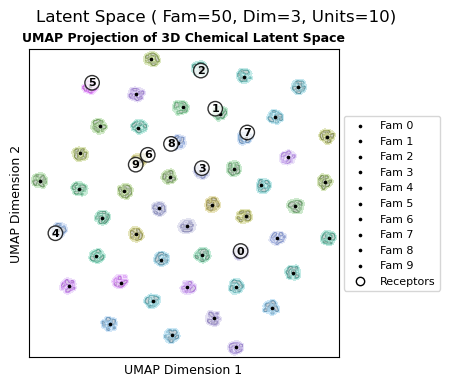

In [52]:
target_families = 50
target_dim = 3
# Plot the latent space visualization for a specific best sample
units_to_plot = [10]
for units in units_to_plot:
    config_keys = [('homomers', target_families, target_dim, units, units),('heteromers', target_families, target_dim, units, units)]
    for config_key in config_keys:
        if config_key in experiments and len(experiments[config_key]['samples']) > 0:
            exp_data = experiments[config_key]['samples'][0]
            print(exp_data['receptor_indices'])
            print(f"\nFitting UMAP for  Fam={target_families}, Dim={target_dim}, Units={units} (Sample 0)...")

            print(exp_data['env'].n_units)
            print(exp_data['env'].n_families)
            print(exp_data['env'].latent_dim)
            print(exp_data['env'].shape_sigma)
            print(exp_data['env'].avg_family_distance)

            fig, ax = plot_latent_umap(exp_data['env'], exp_data['receptor_indices'])
            fig.suptitle(f"Latent Space ( Fam={target_families}, Dim={target_dim}, Units={units})")
            plt.show()

tensor([[0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1],
        [2, 2, 2, 2, 2],
        [3, 3, 3, 3, 3],
        [4, 4, 4, 4, 4],
        [5, 5, 5, 5, 5],
        [6, 6, 6, 6, 6],
        [7, 7, 7, 7, 7],
        [8, 8, 8, 8, 8],
        [9, 9, 9, 9, 9]])

Fitting UMAP for  Fam=10, Dim=10, Units=10 (Sample 0)...
10
10
10
0.1
1.0
Fitting UMAP... (This may take a few seconds)


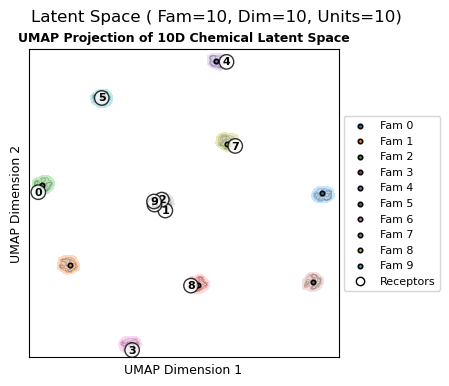

In [7]:
target_families = 10
target_dim = 10
# Plot the latent space visualization for a specific best sample
units_to_plot = [10]
for units in units_to_plot:
    config_keys = [('homomers', target_families, target_dim, units, units),('heteromers', target_families, target_dim, units, units)]
    for config_key in config_keys:
        if config_key in experiments and len(experiments[config_key]['samples']) > 0:
            exp_data = experiments[config_key]['samples'][0]
            print(exp_data['receptor_indices'])
            print(f"\nFitting UMAP for  Fam={target_families}, Dim={target_dim}, Units={units} (Sample 0)...")

            print(exp_data['env'].n_units)
            print(exp_data['env'].n_families)
            print(exp_data['env'].latent_dim)
            print(exp_data['env'].shape_sigma)
            print(exp_data['env'].avg_family_distance)

            fig, ax = plot_latent_umap(exp_data['env'], exp_data['receptor_indices'])
            fig.suptitle(f"Latent Space ( Fam={target_families}, Dim={target_dim}, Units={units})")
            plt.show()

In [10]:
units_to_plot = [10, 20]
for exp_type in ['homomers', 'heteromers']:
    for units in units_to_plot:
        matching_keys = [k for k in experiments.keys() if k[0] == exp_type and k[1] == target_families and k[2] == target_dim and k[3] == units]
        for config_key in matching_keys:
            if len(experiments[config_key]['samples']) > 0:
                exp_data = experiments[config_key]['samples'][0]
                n_receptors = config_key[4]
                label = f"Homomers, Units={units}" if exp_type == 'homomers' else f"Heteromers, Units={units}, Rec={n_receptors}"
                print(f"{label} (Fam={target_families}, Dim={target_dim}):")
                print("shape_sigma:", exp_data['env'].shape_sigma)
                print("avg_family_distance:", exp_data['env'].avg_family_distance)
                print("n_families:", exp_data['env'].n_families)
                print("-" * 30)

Homomers, Units=10 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Homomers, Units=20 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Heteromers, Units=10, Rec=7 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Heteromers, Units=10, Rec=1 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Heteromers, Units=10, Rec=30 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Heteromers, Units=10, Rec=2 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Heteromers, Units=10, Rec=15 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_distance: 5.0
n_families: 10
------------------------------
Heteromers, Units=10, Rec=20 (Fam=10, Dim=10):
shape_sigma: 0.5
avg_family_dis